# 📊 Retail Sales Analysis Project
## Global Superstore Dataset Analysis

### 🎯 Objective:
The goal of this project is to analyze sales data and find useful business insights.
We will understand how the business is performing.

## 🎯 Problem Statement

In this project, we will:
- Analyze sales performance  
- Understand profit trends  
- Do region-wise analysis  
- Find top products  
- Get useful business insights  

## 📦 Step 1: Import Required Libraries

First, we import all the required Python libraries for analysis.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("import liabaries successfully")

import liabaries successfully


## 📂 Step 2: Load Dataset

Now we will load the dataset from a CSV file.

In [11]:
df = pd.read_csv(r"C:\Users\intel i-5\Desktop\Projects\Retail Sales Analysis System\Dataset\Global_Superstore2.csv", encoding="ISO-8859-1")
print("dataload successfully")

dataload successfully


## 📊 Step 3: Dataset Overview

We check the structure of the dataset to understand the columns and data types.

In [12]:
df.shape


(51290, 24)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  str    
 2   Order Date      51290 non-null  str    
 3   Ship Date       51290 non-null  str    
 4   Ship Mode       51290 non-null  str    
 5   Customer ID     51290 non-null  str    
 6   Customer Name   51290 non-null  str    
 7   Segment         51290 non-null  str    
 8   City            51290 non-null  str    
 9   State           51290 non-null  str    
 10  Country         51290 non-null  str    
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  str    
 13  Region          51290 non-null  str    
 14  Product ID      51290 non-null  str    
 15  Category        51290 non-null  str    
 16  Sub-Category    51290 non-null  str    
 17  Product Name    51290 non-null  str    
 1

In [14]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


# 🧹 Data Cleaning

## 📌 Steps Performed
- Handled missing values  
- Removed duplicate records  
- Fixed data types  
- Standardized date format  
- Cleaned text (spaces, case, special characters)  
- Treated outliers (IQR method)  

---

## 📊 Result
- Dataset is clean and ready for analysis  

In [15]:
import pandas as pd
import numpy as np

# =============================
# 1. LOAD DATA
# =============================
# df = pd.read_csv("your_file.csv")

df = df.copy()

# =============================
# 2. INITIAL OVERVIEW (optional but professional)
# =============================
print("Shape:", df.shape)
print(df.info())

# =============================
# 3. HANDLE MISSING VALUES
# =============================
missing_before = df.isnull().sum()

# drop rows with missing values (safe for project datasets)
df.dropna(inplace=True)

missing_after = df.isnull().sum()

# =============================
# 4. REMOVE DUPLICATES
# =============================
df.drop_duplicates(inplace=True)

# =============================
# 5. STANDARDIZE COLUMN NAMES
# =============================
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# =============================
# 6. FIX DATA TYPES
# =============================
# Date conversion (safe handling)
if 'order_date' in df.columns:
    df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

# Numeric conversion (auto-safe)
for col in df.select_dtypes(include='object').columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except:
        pass

# =============================
# 7. CLEAN TEXT COLUMNS
# =============================
text_cols = df.select_dtypes(include='object').columns

for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()
    df[col] = df[col].str.replace(r'[^a-z0-9\s]', '', regex=True)

# =============================
# 8. OUTLIER HANDLING (IQR METHOD)
# =============================
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# =============================
# 9. FINAL CLEAN CHECK
# =============================
print("\n✅ CLEANING COMPLETED")
print("Final Shape:", df.shape)
print(df.head())

Shape: (51290, 24)
<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  str    
 2   Order Date      51290 non-null  str    
 3   Ship Date       51290 non-null  str    
 4   Ship Mode       51290 non-null  str    
 5   Customer ID     51290 non-null  str    
 6   Customer Name   51290 non-null  str    
 7   Segment         51290 non-null  str    
 8   City            51290 non-null  str    
 9   State           51290 non-null  str    
 10  Country         51290 non-null  str    
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  str    
 13  Region          51290 non-null  str    
 14  Product ID      51290 non-null  str    
 15  Category        51290 non-null  str    
 16  Sub-Category    51290 non-null  str    
 17  Product Name    51290 n

C:\Users\intel i-5\AppData\Local\Temp\ipykernel_29868\1028345986.py:47: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
C:\Users\intel i-5\AppData\Local\Temp\ipykernel_29868\1028345986.py:50: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:
C:\Users\intel i-5\AppData\Local\Temp\ipykernel_29868\1028345986.py:59: Pandas4Warning: For backward c


✅ CLEANING COMPLETED
Final Shape: (6080, 24)
       row_id      order_id order_date ship_date     ship_mode customer_id  \
15609   35227  ca2013162082 2013-03-15  18032013   first class     js15880   
15632   33221  ca2014126865 2014-12-06  08122014  second class     np18325   
15639   32455  ca2013149314 2013-07-03  08072013  second class     gb14530   
15644   31946  ca2013160745 2013-12-12  17122013  second class     ar10825   
15648   33097  ca2013121034 2013-08-09  11082013  second class     jf15565   

        customer_name    segment         city       state  ...     product_id  \
15609  john stevenson   consumer    harlingen       texas  ...  offar10001044   
15632    naresj patel   consumer    san diego  california  ...  offpa10003039   
15639     george bell  corporate  los angeles  california  ...  furch10002126   
15644  anthony rawles  corporate    vancouver  washington  ...  tecph10003273   
15648      jill fjeld   consumer       dallas       texas  ...  offpa10001994   

## 🧹 Data Cleaning

- Missing values were removed  
- Duplicate records were deleted  
- Data types were corrected  
- Date format was standardized  
- Text data was cleaned (spaces, lowercase, special characters)  
- Outliers were handled using the IQR method  

## ✅ Result

The cleaned dataset is ready for analysis.

## 💾 Save Cleaned Data  
Cleaned dataset saved in the **data folder** for analysis.

### 📌 Output:
- CSV file  
- Excel file (optional)

In [16]:
output_path = r"C:\Users\intel i-5\Desktop\Projects\Retail Sales Analysis System\Dataset\cleaned_data.csv"

df.to_csv(output_path, index=False)

print("Saved successfully:", output_path)

Saved successfully: C:\Users\intel i-5\Desktop\Projects\Retail Sales Analysis System\Dataset\cleaned_data.csv


## 📊 Step 5: Exploratory Data Analysis (EDA)

EDA helps us understand patterns in the data.

### 🎯 What we do in EDA:

1. Analyze sales and profit trends.
2. Check relationships between categories and regions.
3. Identify top performing products.
4. Understand customer and segment behavior.

EDA helps us find hidden insights in the data.

## 📈 KPI Analysis (Key Performance Indicators)

We calculate the most important business metrics to understand overall performance of the store.

### 🎯 Key KPIs:

1. 💰 Total Sales  
2. 📦 Total Orders  
3. 📉 Total Profit  
4. 📊 Average Order Value  
5. 📈 Profit Margin (%)  

---

### 🧠 KPI Insights:

- 💰 Total Sales shows overall revenue generated.  
- 📦 Total Orders shows total customer transactions.  
- 📉 Total Profit shows actual earnings after cost.  
- 📊 Average Order Value shows average spending per order.  
- 📈 Profit Margin shows business efficiency in percentage.  

---

### 📌 Conclusion:

These KPIs help us understand how well the business is performing in terms of sales, profitability, and customer value.

In [17]:
# =============================
# KPI ANALYSIS
# =============================

# 1. Total Sales
total_sales = df['sales'].sum()

# 2. Total Orders
total_orders = df['order_id'].nunique()

# 3. Total Profit
total_profit = df['profit'].sum()

# 4. Average Order Value
avg_order_value = total_sales / total_orders

# 5. Profit Margin (%)
profit_margin = (total_profit / total_sales) * 100

# Print Results
print("💰 Total Sales:", total_sales)
print("📦 Total Orders:", total_orders)
print("📉 Total Profit:", total_profit)
print("📊 Average Order Value:", avg_order_value)
print("📈 Profit Margin (%):", profit_margin)

💰 Total Sales: 294608.1019
📦 Total Orders: 3786
📉 Total Profit: 64602.3814
📊 Average Order Value: 77.8151352086635
📈 Profit Margin (%): 21.9282433114919


## 📊 Step 7: Data Visualization

We use graphs to understand data in a better and more visual way.

---

### 🎯 Visualizations:

1. 📦 Sales by Category (Bar Chart)  
2. 📉 Profit by Region (Bar Chart)  
3. 📈 Monthly Sales Trend (Line Chart)  
4. 🏆 Top Products (Bar Chart)   
5. 🧑‍🤝‍🧑 Sales by Segment (Pie Chart)  

---


## 📦 Sales by Category

This chart shows total sales distribution across different product categories.

### 📊 Key Insight:
- Identifies which category generates the highest revenue.
- Helps in understanding product demand.

### 📌 Conclusion:
Technology and Office Supplies categories play a key role in overall sales performance.

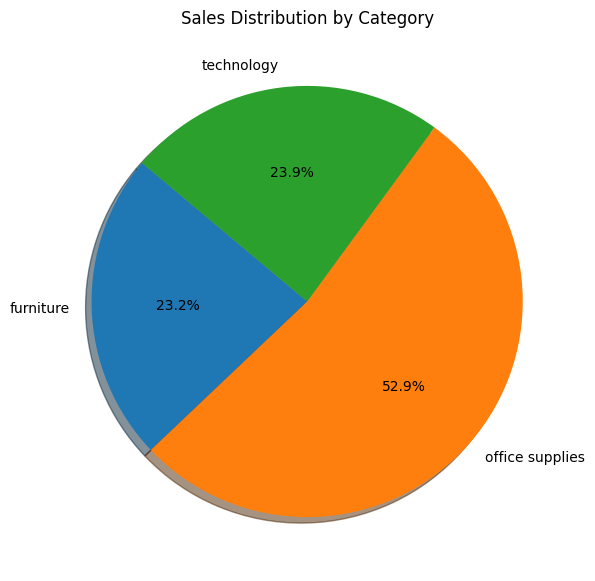

In [18]:
import matplotlib.pyplot as plt

# Clean data
df['category'] = df['category'].str.strip()
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')
df = df.dropna(subset=['category', 'sales'])

# Group
category_sales = df.groupby('category')['sales'].sum()

# Pie chart
plt.figure(figsize=(7,7))

plt.pie(
    category_sales,
    labels=category_sales.index,
    autopct=lambda p: f'{p:.1f}%',
    startangle=140,
    shadow=True
)

plt.title("Sales Distribution by Category")

plt.savefig("../images/sales_by_category_pie.png", dpi=300, bbox_inches='tight')

plt.show()

## 📉 Profit by Region

This chart represents profit distribution across different regions.

### 📊 Key Insight:
- Shows which region is most profitable.
- Helps identify weak-performing regions.

### 📌 Conclusion:
Some regions generate strong profits while others need improvement in strategy.

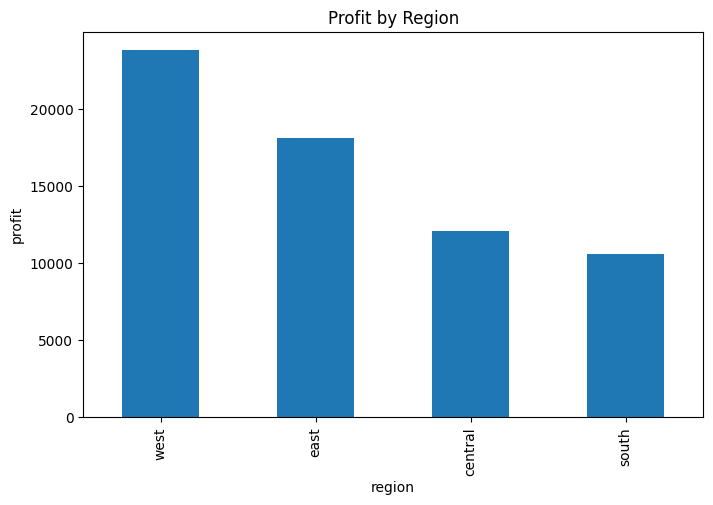

In [19]:
import matplotlib.pyplot as plt

# Clean data
df['region'] = df['region'].astype(str).str.strip()
df['profit'] = pd.to_numeric(df['profit'], errors='coerce')
df = df.dropna(subset=['region', 'profit'])

# Group + sort (highest to lowest)
region_profit = df.groupby('region')['profit'].sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(8,5))
region_profit.plot(kind='bar')

plt.title("Profit by Region")
plt.xlabel("region")
plt.ylabel("profit")

# Save image (no folder creation)
plt.savefig("../images/profit_by_region.png", dpi=300, bbox_inches='tight')

plt.show()

## 📈 Monthly Sales Trend

This chart shows how sales change over time on a monthly basis.

### 📊 Key Insight:
- Identifies seasonal patterns in sales.
- Shows growth or decline trends.

### 📌 Conclusion:
Sales fluctuate monthly, indicating seasonal demand patterns.

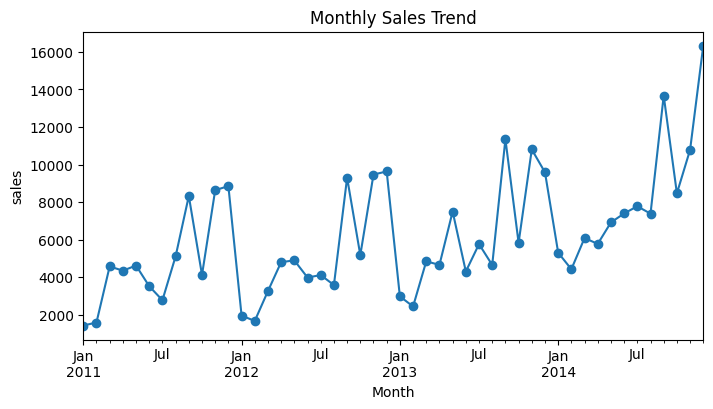

In [20]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['Month'] = df['order_date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['sales'].sum()

plt.figure(figsize=(8,4))
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.ylabel("sales")

plt.savefig("../images/monthly_sales_trend.png", dpi=300, bbox_inches='tight')

plt.show()

## 🏆 Top Products Analysis

This chart highlights the top 10 best-selling products based on sales.

### 📊 Key Insight:
- Shows which products contribute most to revenue.
- Helps in inventory and marketing planning.

### 📌 Conclusion:
A small number of products generate most of the total sales.

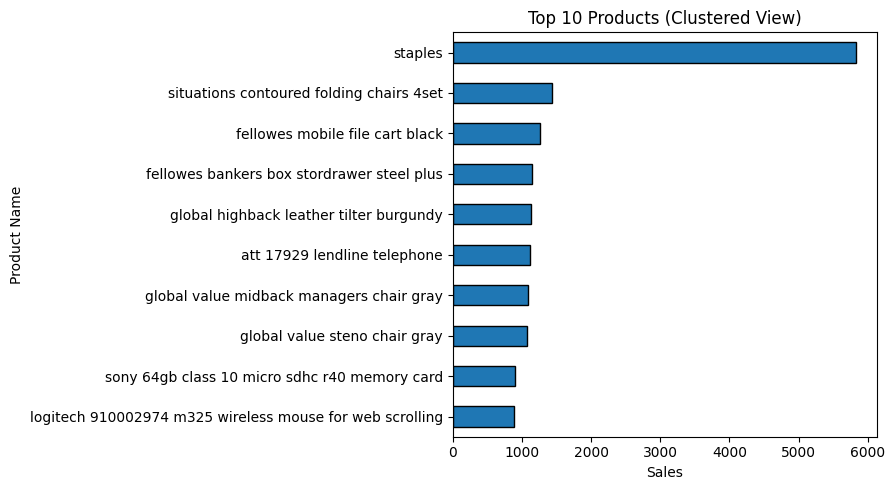

In [21]:
import os
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

top_products = df.groupby('product_name')['sales'].sum() \
    .sort_values(ascending=True).tail(10)

top_products.plot(kind='barh', edgecolor='black')

plt.title("Top 10 Products (Clustered View)")
plt.xlabel("Sales")
plt.ylabel("Product Name")

# ✅ SAFE IMAGE PATH (IMPORTANT FIX)
img_path = os.path.join("images", "top_products.png")

plt.savefig(r"C:\Users\intel i-5\Desktop\Projects\Retail Sales Analysis System\Images\top_products.png", dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

## 🧑‍🤝‍🧑 Sales by Segment

This pie chart shows sales contribution from different customer segments.

### 📊 Key Insight:
- Identifies most valuable customer segment.
- Shows distribution of customer base.

### 📌 Conclusion:
One or two segments dominate total sales contribution.

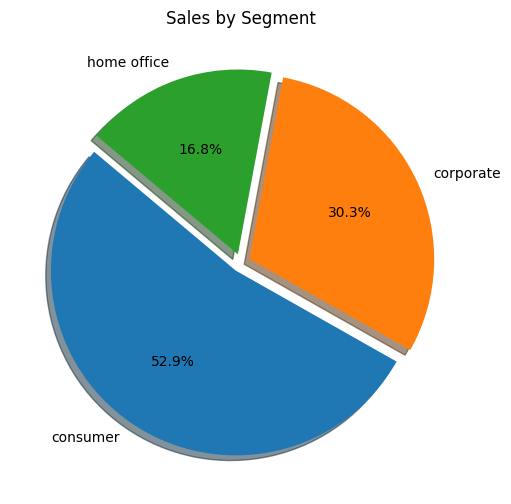

In [22]:
import matplotlib.pyplot as plt

df.columns = df.columns.str.strip().str.lower()

df['segment'] = df['segment'].astype(str).str.strip()
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')
df = df.dropna(subset=['segment', 'sales'])

segment_sales = df.groupby('segment')['sales'].sum()

plt.figure(figsize=(6,6))

plt.pie(
    segment_sales,
    labels=segment_sales.index,
    autopct='%1.1f%%',
    startangle=140,
    shadow=True,
    explode=[0.05]*len(segment_sales)
)

plt.title("Sales by Segment")

# ✅ FIXED PATH
plt.savefig(r"C:\Users\intel i-5\Desktop\Projects\Retail Sales Analysis System\Images\Sales by Segment.png", dpi=300, bbox_inches='tight')

plt.show()

## 📊 Step 8: Key Insights

After analyzing the data, we found the following important insights:

- 💰 Sales are highest in the Technology category  
- 📉 Some regions have high sales but low profit  
- 🏆 A few top products generate most of the revenue  
- 🧑‍🤝‍🧑 Consumer segment contributes the highest share of sales  
- 📈 Sales and profit are positively related but not always proportional  

---

## 📌 Final Conclusion:

The business is performing well in terms of sales, but profit optimization is required in certain regions and categories to improve overall efficiency.